Epoch 1/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0586 - val_loss: 0.0253
Epoch 2/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0298 - val_loss: 0.0254
Epoch 3/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0301 - val_loss: 0.0260
Epoch 4/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0298 - val_loss: 0.0254
Epoch 5/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0298 - val_loss: 0.0250
Epoch 6/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0297 - val_loss: 0.0252
Epoch 7/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0297 - val_loss: 0.0248
Epoch 8/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0300 - val_loss: 0.0256
Epoch 9/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0300 - val_loss: 0.0248
Epoch 10/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0299 - val_loss: 0.0251
Epoch 11/15
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0300 - val_loss: 0.0248
Epoch 12/15
1095/1095 ━━━━━━━━

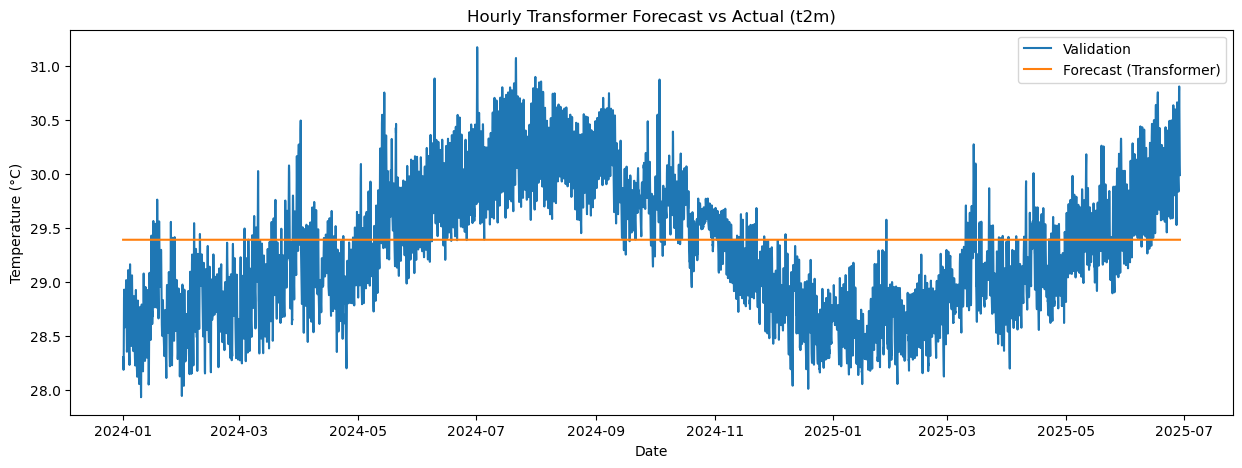


MAE: 0.5236353337625578
RMSE: 0.6206152300751305


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LayerNormalization, MultiHeadAttention, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

# Load data
df = pd.read_csv("../../data/processed/sfax_weather_features.csv", parse_dates=['valid_time'])
df = df.set_index('valid_time')

# Scaling
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['t2m']])

# Create supervised sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 24
X, y = create_sequences(df_scaled, seq_length)

# Train/Validation split
train_size = df.loc[:'2023-12-31'].shape[0] - seq_length
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:], y[train_size:]

# Transformer Block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x + inputs)

    x_ff = Dense(ff_dim, activation="relu")(x)
    x_ff = Dropout(dropout)(x_ff)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    return LayerNormalization(epsilon=1e-6)(x + x_ff)

# Define Transformer model
inputs = Input(shape=(seq_length, 1))
x = transformer_encoder(inputs, head_size=32, num_heads=2, ff_dim=64, dropout=0.1)
x = Flatten()(x)
outputs = Dense(1)(x)

model_transformer = Model(inputs, outputs)
model_transformer.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")

# Training
history_transformer = model_transformer.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)

# Prediction
y_pred_scaled_transformer = model_transformer.predict(X_val)
y_pred_transformer = scaler.inverse_transform(y_pred_scaled_transformer)
y_val_true = scaler.inverse_transform(y_val)

# Plot
val_index = df.index[train_size + seq_length:]
plt.figure(figsize=(15,5))
plt.plot(val_index, y_val_true, label='Validation')
plt.plot(val_index, y_pred_transformer, label='Forecast (Transformer)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Hourly Transformer Forecast vs Actual (t2m)')
plt.legend()
plt.show()

# Evaluation
mae_transformer = mean_absolute_error(y_val_true, y_pred_transformer)
rmse_transformer = np.sqrt(mean_squared_error(y_val_true, y_pred_transformer))
print()
print(f"MAE: {mae_transformer}")
print(f"RMSE: {rmse_transformer}")
